# Slit through focus analysis for SM slit alignment 

**Creator :** Fabrice MADEC *(Laboratoire d'astrophysique de Marseille)*

**Editor :** Romain LHOUSSAINE BEN BRAHIM *(Laboratoire d'astrophysique de Marseille)*

YM modified to run at Subaru

(The leg #1 of the hexapod was replaced because the motor was broken. Now home position of the slit chages, measure the current home position via throughfocus)

**Date :** 13 January 2025

**Data required:** I ran the following command to find the right focus. Because the home position shifted on the detecotr, I also corrected the position ahead of the slit troughfocus sequence. 

    iic slit throughfocus exptime=2 position=-2,2.5,60 cam=b1,r1 head='enu_sm1 slit move absolute Y=-0.093 Z=0.066'

In [1]:
%load_ext autoreload
%autoreload 2

## 0. Librairies, constants and parameters

### 0.1. Classic librairies

In [3]:
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
import os
import datetime
from matplotlib import style
from matplotlib.offsetbox import AnchoredText

# For multiprocssing
from concurrent.futures import ProcessPoolExecutor
import time
from functools import partial

import glob

### 0.2. LAM Librairies

In [4]:
# import LAM library for logbook, data analysis...
from pfs.lam.sacFileHandling import Logbook, constructFilelist
import pfs.lam.imageAnalysis as imeas
from pfs.lam.slitFocusAnalysis import *
from pfs.lam.style import colors
from pfs.lam.opdb import *
from pfs.lam.imqual2Csv import main as getImqual

# To read data manually
from pfs.lam.linePeaksList import filterPeakList
import astropy.io.fits as fio
from pfs.lam.analysisPlot import plotRoiPeak, plotPeaksBrightness
from pfs.lam.detAnalysis import *

### 0.3. Constants & parameters

#### 0.3.1 Constants & Paths

In [5]:
# Style sheets reference
style.use('ggplot')

In [6]:
# Distance between engtopend & engbotend fibers
CST_DIST_FIBERS = 138.84

In [7]:
smId = 1

In [8]:
imgPath = f'/work/moritani/spsAIT/202603/' # WARNING : You must verify that you are choosing the right SM folder !!
print(imgPath)

/work/moritani/spsAIT/202603/


In [9]:
MAX_PROCESS = 30

#### 0.3.1 Parameters of the slit

In [29]:
# Before correction
#experimentIds = [60627]     # Ids needed for the slit through focus analysis
# test all SMs, after SM1 correction
experimentIds = [60658]     # Ids needed for the slit through focus analysis
lamps = ['Ne']
exptime = 2
fiberType = 'ENGINEERING'

In [11]:
# Experiment Ids used for evalutating the background
#bck_expId     = 260                  #
doBck         = True                  # If you don't made any background, you can set doBck as True to retrieve the median value of the image

In [12]:
com           = True                  #
corrector     = False                 #
doSave        = True                  # Parameter that allow to save the through slit focus on the distant computer 
head          = 0                     #
tail          = 0                     #
dfs           = []                    # Dataframe containing all 

In [13]:
threshold = 300                   #
radius = 60                       #
doPrint = False                   #
doPlot = True                    #
roi_size = 24                    # on sps camera
seek_size = None

# Option to define outputs, plots
roiPlot = True
plotPeaksFlux = True
doFit = True    # activate 2D-gaussian fit to measure spot size
doLSF = False

In [14]:
fwhm_radius = radius              #
fwhm_method = 'gaussian'          #

In [15]:
vline = True
index = 'fca_x'

In [16]:
thres_neighbor = -0.1             #
doNeighborFilter = True           #
plotModel = True

## 1. Downloading Data

### 1.0. Theorical Zeemax data

According to Fabrice, it is not necessary now.

In [15]:
# Filepath of data model
pmodel = "/work/moritani/codes/dev_sps_analysis/notebooks/optical/input/slit"
file = 'slit-defParam-Ouverture100-fiber65.csv'

In [16]:
# 1: Loading Zeemax data
zemaxData = pd.read_csv('%s/%s' % (pmodel, file), delimiter=" ")

In [17]:
# 2: Loading Zeemax data for medium fibers
zemaxMidFit = imeas.fitparabola(x=zemaxData.Slitdefocus, y=zemaxData.MidFiber, deg=15, focus='max')

In [18]:
# 3: Loading Zeemax data for extreme fibers
zemaxEndFit = imeas.fitparabola(x=zemaxData.Slitdefocus, y=zemaxData.ExtremeFiber, deg=15, focus='max')

### 1.1. Experimental data

In [ ]:
# Loading data from the data base
experiments = pd.read_sql_query('select * from Experiment where type="slitAlignment" order by experimentId desc',
                                con='sqlite:////data/ait/experimentLog-sac.db', index_col='experimentId')

In [104]:
# Data manipulation to recover the fiber and exptime informations
experiments['exptime'] = [Logbook.getParameter(experimentId, 'exptime') for experimentId in experiments.index]
experiments['fiber'] = [Logbook.getParameter(experimentId, 'fiber', doRaise=False) for experimentId in experiments.index]

In [105]:
# Display of the 4 acquisitions made on the SacSequence Panel
experiments[experiments.index.isin(experimentIds)]

,name,visitStart,visitEnd,type,cmdStr,comments,anomalies,startdate,cmdError,exptime,fiber
experimentId,,,,,,,,,,,
508,SM4_Slit_Alignment,16128,16187,slitAlignment,"spsait slit align exptime=2.0 position=-2,2.5,...",after alignment,,2023-07-26T06:54:30,,2.0,engtopend
507,SM4_Slit_Alignment,16068,16127,slitAlignment,"spsait slit align exptime=2.0 position=-2,2.5,...",after alignment,,2023-07-26T06:36:31,,2.0,engbotend
506,SM4_Slit_Alignment,16008,16067,slitAlignment,"spsait slit align exptime=2.0 position=-2,2.5,...",after alignment,,2023-07-26T06:19:08,,2.0,engtopmid
505,SM4_Slit_Alignment,15948,16007,slitAlignment,"spsait slit align exptime=2.0 position=-2,2.5,...",after alignment with keyword,,2023-07-26T06:01:11,,2.0,engbotmid


### 1.3 Process experimental data at Subaru

In [42]:
# Hilo
drpPath, repo, rerun = '/work/datastore', 'repo', 'drpActor/reductions/'

outpath = f"{imgPath}slitThroughFocus/"
specId=1
arm = 'r'

drpVer='gen3'

print(outpath)

/work/moritani/spsAIT/202603/slitThroughFocus/


In [43]:
# redefine when you change specId and experimentId
def task(visitId, cam=f"r{specId}", rerun=rerun, experimentId=experimentIds[0],
         outpath=outpath, drpPath=drpPath, repo=repo,
         roi_size=roi_size, seek_size=seek_size, doBck=doBck, roiPlot=roiPlot,
         plotPeaksFlux=plotPeaksFlux, doFit=doFit, doLSF=doLSF, doPrint=doPrint,
         fiberType=fiberType, drpVer=drpVer, specId=specId):

    arm='r'
    imfile = glob.glob(f'{postISRCCDdir}/*/*/*{visitId}*r{specId}*.fits')[0]

    csvPath = os.path.join(outpath,f"sm{specId}",f"Exp{experimentId}",rerun,f"roi{roi_size}",f"doBck{doBck}")
    # print(imfile, csvPath)

    if not os.path.exists(csvPath):
        os.makedirs(csvPath,exist_ok =True)

    cam = f"{arm}{specId}"
    #print(f'Processing {cam}: {imfile}')
    #peaklist = f"/work/moritani/spsAIT/202311/peaklist/SM{specId}_peakList_kr_{cam}_20240419_iis.csv"
    #peaklist = f"/work/moritani/spsAIT/202311/peaklist/SM{specId}_peakList_ne_{cam}_20240415_iis.csv"
    peaklist = f"/work/moritani/spsAIT/202311/peaklist/SM{specId}_peakList_ne_{cam}_20240415_iis.csv"
    peaks = filterPeakList(peaklist, arm, lamps) if peaklist is not None else None

    fits = fio.open(imfile)

    dataId=dict(arm=arm, spectrograph=specId, visit=visitId)
    imageInfo = dict(dataId)
    imageInfo.update(filename=imfile)
    imageInfo.update(experimentId=experimentId)    

    # Image HDU1
    image = fits[1].data

    if roiPlot and (peaklist is not None):
        RoiPlotTitle = f"Peaklist roiPlot {cam.upper()} Exp{experimentId} - visit{visitId} - roi_size={roi_size}\n"
        plotRoiPeak(image, peaks, roi_size=roi_size, savePlotFile=os.path.join(csvPath,f"{cam}_{visitId}_rawPeak"),raw=True,doSave=True, title=RoiPlotTitle )

     
    data = getFullImageQuality(image, peaklist, imageInfo=imageInfo,
                               roi_size=roi_size, EE=[3,5], seek_size=seek_size,
                               com=True, doBck=doBck, doFit=doFit, doLSF=doLSF, doSep=True,fullSep=False,
                               doPlot=roiPlot, doPrint=doPrint,
                               mask_size=20, threshold=50, subpix=5 , maxPeakDist=80,
                               maxPeakFlux=40000, minPeakFlux=2000, calexpMask=None)
        
    now = datetime.now() # current date and time\n",
    date_time = now.strftime("%Y%m%dT%Hh%M")
    lwh=None

    csvName = f"Imquality_{cam}_Exp{experimentId}_{visitId}_{date_time}.csv"

    data.to_csv(os.path.join(csvPath, csvName))
    if roiPlot:
        RoiPlotName = f"roiPlot_{cam}_Exp{experimentId}_{visitId}_{date_time}"
        RoiPlotTitle = f"roiPlot {cam.upper()} Exp{experimentId} - visitId {visitId} - roi_size={roi_size}\n{date_time}"
        plotRoiPeak(image, data, roi_size, savePlotFile=os.path.join(csvPath, RoiPlotName),raw=False,doSave=True, title=RoiPlotTitle)
    if plotPeaksFlux:
        plotPeaksBrightness(data, doSave=True, savePlotFile=os.path.join(csvPath,f"{cam}_{visitId}_fluxes_{'_'.join(lamps)}{exptime:.0f}s_lwh{lwh}"),
                            plot_title=f"{cam}_{visitId} - {'_'.join(lamps)} exptime {exptime}s lwh {lwh}")
        
    
    return "OK"

In [44]:
# Get visit Range

postISRCCDdir = '/data/drp/datastore/drpActor/reductions/20260302T170022Z/postISRCCD/'

for experimentId in experimentIds:
    #visitStart, visitEnd = 140315 , 140327
    visitStart, visitEnd = getVisitRange_fromWeb(experimentId, url="http://133.40.164.16/sps-logs/index.html")
    print(f"{experimentId}: {visitStart} -- {visitEnd}")
    #visitId = visitStart
    visitId = range(visitStart, visitEnd+1)

    start_time = time.time()

    task_partial = partial(task, cam=f"r{specId}", rerun=rerun, experimentId=experimentId,
                           outpath=outpath, drpPath=drpPath, repo=repo, roi_size=roi_size, seek_size=seek_size, 
                           doBck=doBck, roiPlot=roiPlot, plotPeaksFlux=plotPeaksFlux, doFit=doFit, doLSF=doLSF, 
                           doPrint=doPrint, fiberType=fiberType, drpVer=drpVer, specId=specId)

    with ProcessPoolExecutor(max_workers=8) as executor:
        results = list(executor.map(task, visitId))

    end_time = time.time()
    print(f"Processed {len(results)} out of {len(visitId)} items in {end_time - start_time:.2f} seconds")

    

60658: 140364 -- 140404
Processed 41 out of 41 items in 584.20 seconds


### 1.4 Select required data

Pick up the data for "engtopend", "engbotend", "engtopmid", "engbotmid" fibers (i.e. fh = 1, 651, 316, 336)

And setect wavelength nearby center.

In [45]:
fibers = [1, 651, 316, 336]
fibername = {1:'engtopend', 651:'engbotend', 316:'engtopmid', 336:'engbotmid'}
wavelength = [808.46801]

In [46]:
columns=['fiber', 'wavelength', 'oid_x', 'oid_y', 'fcaX', 'visit', 'EE3', 'EE5']
df = pd.DataFrame(columns=columns)

for experimentId in experimentIds:
    visitStart, visitEnd = getVisitRange_fromWeb(experimentId, url="http://133.40.164.16/sps-logs/index.html")
    print(f"{experimentId}: {visitStart} -- {visitEnd}")
    #visitId = visitStart
    csvPath = os.path.join(outpath,f"sm{specId}",f"Exp{experimentId}",rerun,f"roi{roi_size}",f"doBck{doBck}")

    #visitEnd=136473
    for visitId in range(visitStart, visitEnd+1):
        datafile = glob.glob(f'{csvPath}/*{visitId}*.csv')[-1]   # select the last measurement
        print(f'read {datafile}\r', end='')
        df_tmp = pd.read_csv(datafile, usecols=columns).drop_duplicates(subset=['oid_x', 'oid_y'])
        df_tmp = df_tmp[df_tmp.fiber.isin(fibers)&df_tmp.wavelength.isin(wavelength)]
        #print(df_tmp.fiber)
        df = pd.concat([df, df_tmp])

60658: 140364 -- 140404
read /work/moritani/spsAIT/202603/slitThroughFocus/sm1/Exp60658/drpActor/reductions/roi24/doBckTrue/Imquality_r1_Exp60658_140404_20260312T21h11.csv

In [50]:
%matplotlib inline

In [47]:
df_mean = pd.DataFrame(columns=['fiber', 'amplitude', 'mean', 'sigma', 'offset', 'fwhm'])

fig = "slit_focusthrough"; plt.close(fig);
fig, axs = plt.subplots(num=fig, nrows=1, ncols=1, sharex=True,
                        figsize=(8,5))

ax_list = fig.get_axes()
    
#axs.axis('equal')
#axs.set_xlim(xmin=-0, xmax=4176)
#axs.set_ylim(ymin=0., ymax=4176)
#axs.set_xlabel('Cobra convergence [um]')
#axs.set_ylabel('Raster residual (95%) [um]')
text=''
for i,f in enumerate(fibers):
    axs.scatter(df[df.fiber==f].fcaX, df[df.fiber==f].EE3, marker='o', color=colors[i], label=f'fh={f} {fibername[f]}')
    thfoc, parfit = imeas.fitgauss1D(df[df.fiber==f].fcaX.values, df[df.fiber==f].EE3.values)
    axs.vlines(parfit['mean'], ymin=-0.1, ymax=1.2, color=colors[i])
    axs.plot(thfoc.x, thfoc.y, color=colors[i])
    axs.annotate(f'{parfit["mean"].values[0]:.3f}',(parfit['mean']+0.1, parfit['amplitude']+0.1),
                 color=colors[i])
    text = text + f'fh={f}  mean={parfit["mean"].values[0]:.3f},'

    parfit['fiber'] = f
    df_mean = pd.concat([df_mean,parfit])
    #print(thfoc, parfit)
#axs.set_title(f'median:(dx,dy)=({dx_mean:.1f}, {dy_mean:.1f}) pix (r1)')
axs.legend(ncol=1)
fig.suptitle(text, fontsize=9)

plt.show()

In [48]:
#fig.savefig(f'slitFocus_r1_beforecorrection.png')
fig.savefig(f'slitFocus_r1_duringrun27c.png')

In [52]:
focus_adjustment =  (df_mean[df_mean.fiber==316]['mean'] + df_mean[df_mean.fiber==336]['mean'])/2.

tilt_ry = (df_mean[df_mean.fiber==651]['mean'] - df_mean[df_mean.fiber==1]['mean'])
angle = np.arctan(tilt_ry/CST_DIST_FIBERS)
angle_degree = np.rad2deg(angle)


print(f'defocus: {focus_adjustment.values[0]:.4f} mm')
print(f'tilt-Y : {angle_degree.values[0]:.4f} deg')

defocus: 0.4598 mm
tilt-Y : -0.1104 deg


Calc new home position

* X-shift (defocus): measured value should be added
* Y-tile (pitch): measured value should be subetracted

home (2025.11): [ -0.522 , 0.097, 205.146025 , 0.0,  0.059076 , -120 ]

home: [ -0.522 + (-0.1833), 0.097, 205.146025, 0.0, 0.059076 - 0.0471, -120 ] = [ -0.7053, 0.097, 205.146025, 0.0, 0.011976, -120 ]

during the run 26

home: [ -0.7053+0.4409, 0.097, 205.146025, 0.0, 0.011976+0.1002, -120 ] = [-0.2644, 0.097, 205.146025, 0.0, 0.112176, -120 ] 

during the run 27

home: [ -0.7053+0.4585 , 0.097, 205.146025, 0.0, 0.011976 - (-0.1104), -120 ] = [-0.2468, 0.097, 205.146025, 0.0, 0.122376, -120]

Note: the above number was calculated in the middle of analysis

In [29]:
[ -0.7053+0.4585 , 0.097, 205.146025, 0.0, 0.011976 - (-0.1104), -120 ]

[-0.24680000000000002, 0.097, 205.146025, 0.0, 0.122376, -120]

In [134]:
df[(df.fcaX>=-0.2)&(df.fcaX<=0.2)][['visit', 'fcaX']]

,visit,fcaX
96,119105,-0.16998
103,119105,-0.16998
104,119105,-0.16998
111,119105,-0.16998
96,119106,-0.08999
103,119106,-0.08999
104,119106,-0.08999
111,119106,-0.08999
96,119107,-0.01999
103,119107,-0.01999


The home position now is

    home: [ -0.428, 0.19, 205.080025, 0.0, 0.031776, -120 ]

In [ ]:
df_mean = pd.DataFrame(columns=['fiber', 'amplitude', 'mean', 'sigma', 'offset', 'fwhm'])

fig = "slit_focusthrough"; plt.close(fig);
fig, axs = plt.subplots(num=fig, nrows=1, ncols=1, sharex=True,
                        figsize=(8,5))

ax_list = fig.get_axes()
    
#axs.axis('equal')
#axs.set_xlim(xmin=-0, xmax=4176)
#axs.set_ylim(ymin=0., ymax=4176)
#axs.set_xlabel('Cobra convergence [um]')
#axs.set_ylabel('Raster residual (95%) [um]')
text=''
for i,f in enumerate(fibers):
    x0 = df[(df.fiber==f)&(df.fcaX==-2.0)].oid_x.values
    y0 = df[(df.fiber==f)&(df.fcaX==-2.0)].oid_y.values

    axs.scatter(df[df.fiber==f].oid_x-x0, df[df.fiber==f].oid_y-y0, marker='o', color=colors[i], label=f'fh={f}')
    #thfoc, parfit = imeas.fitgauss1D(df[df.fiber==f].fcaX.values, df[df.fiber==f].EE3.values)
    #axs.vlines(parfit['mean'], ymin=-0.1, ymax=1.2, color=colors[i])
    #axs.plot(thfoc.x, thfoc.y, color=colors[i])
    #axs.annotate(f'{parfit["mean"].values[0]:.3f}',(parfit['mean']+0.1, parfit['amplitude']+0.1),
    #             color=colors[i])
    text = text + f'fh={f} mean={parfit["mean"].values[0]:.3f},'

    parfit['fiber'] = f
    df_mean = pd.concat([df_mean,parfit])
    #print(thfoc, parfit)
#axs.set_title(f'median:(dx,dy)=({dx_mean:.1f}, {dy_mean:.1f}) pix (r1)')
axs.legend(ncol=1)
fig.suptitle(text, fontsize=9)

plt.show()

## 2. Data Analysis

### 2.1. Compile the maximum brightness according to the focus's displacement

In [27]:
for experimentId in experimentIds:
    dfs.append(getSlitTF(experimentId=experimentId, com=com, head=head, tail=tail, doBck=doBck, doPrint=doPrint, doPlot=doPlot))

cube = pd.concat(dfs)

OperationalError: unable to open database file

### 2.2. Plot framed energy by 20/40 pixels over the optical axis

#### 2.2.1. Remove outliers

In [28]:
if doNeighborFilter :
    cube2 = imeas.neighbor_outlier_filter(cube, "EE20",thres_neighbor, absolute=True)

NameError: name 'cube' is not defined

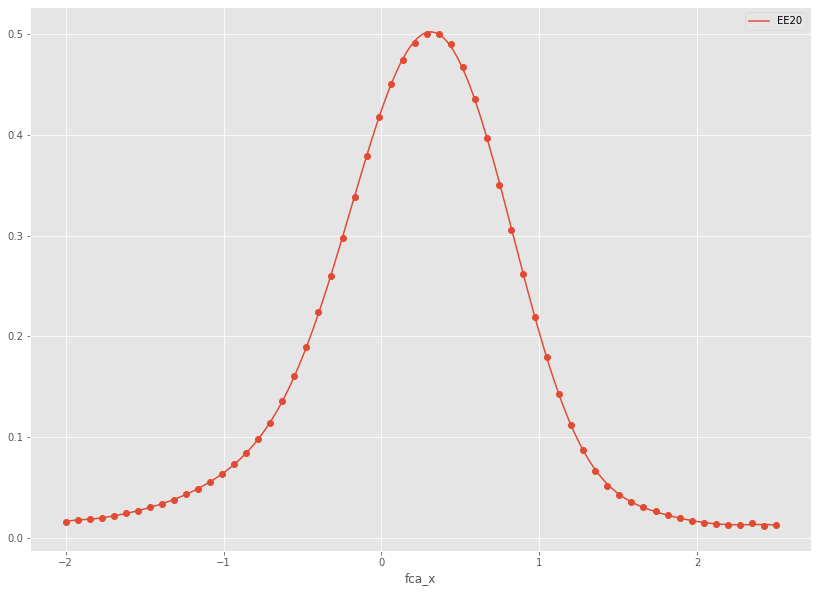

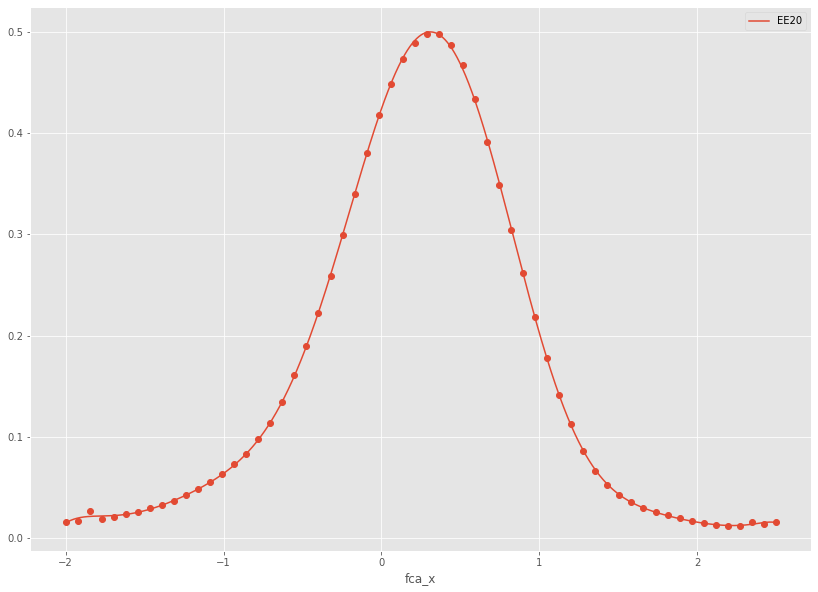

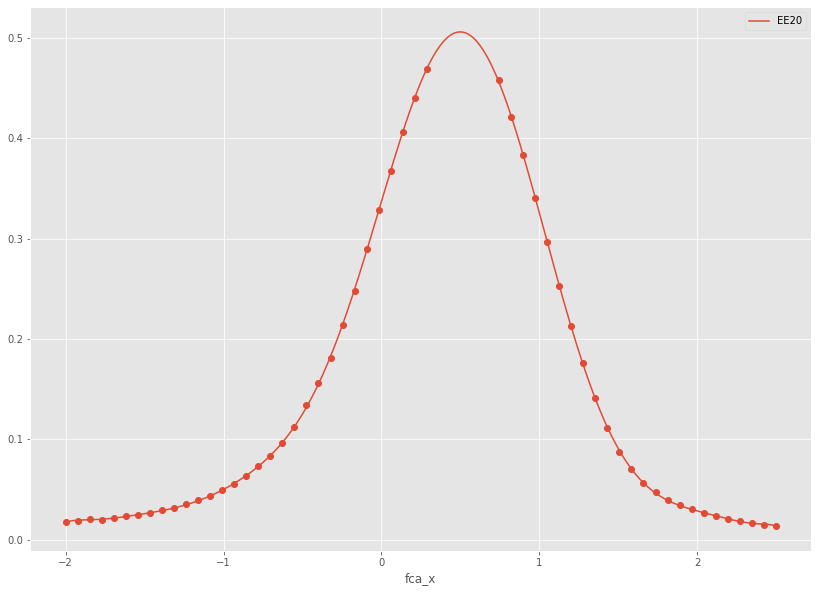

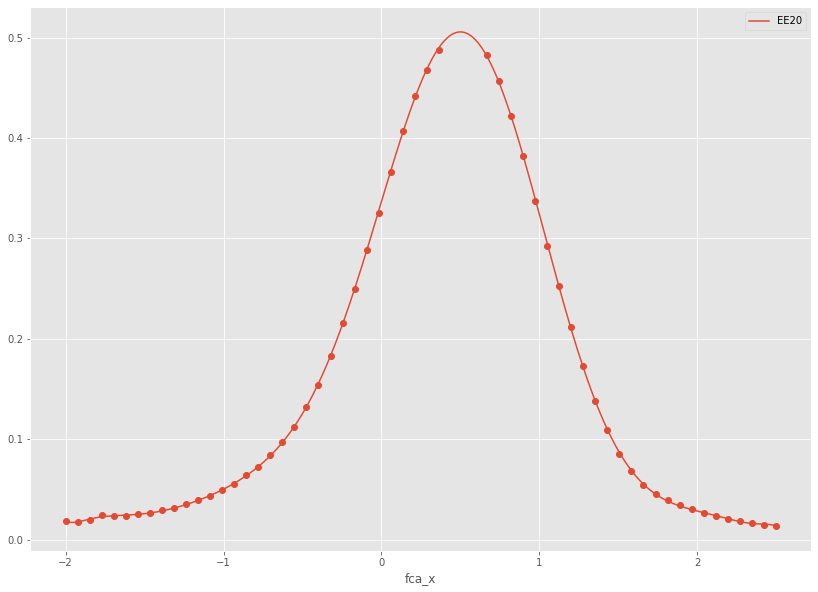

In [108]:
thfocModel= fitFocusData(cube2[cube2.EE20_nbh_flag], corrector=corrector, doPlot=doPlot)

#### 2.2.3. ...

In [26]:
focusModel = getFocusModel(thfocModel)

NameError: name 'thfocModel' is not defined

## 3. Tilt & Focus determination

### 3.1. Tilt determination

In [25]:
# 1 : Computing position difference between both extreme fibers
[tilt_ry] = focusModel.fca_x[focusModel.fiber.str.match('\w{3}botend')==True].values - focusModel.fca_x[focusModel.fiber.str.match('\w{3}topend')==True].values

NameError: name 'focusModel' is not defined

In [111]:
# 2 : Computing tilt on y axis (rad)
angle=np.arctan(tilt_ry/CST_DIST_FIBERS)

In [112]:
# 3 : Converting in degrees
angle_degre=(angle*180)/(np.pi)

In [113]:
# 4 : Displying the tilt value
print("There is a tilt of %.3f milidegrees" %(angle_degre*1000))

There is a tilt of -0.555 milidegrees


### 3.2. Focus determination

In [114]:
# 1 : Calculating mean value between the both mid position fibers
[focus_adjustment] = ((focusModel.fca_x[focusModel.fiber.str.match('\w{3}botmid')==True].values + focusModel.fca_x[focusModel.fiber.str.match('\w{3}topmid')==True].values)/2) 

In [115]:
# 2 : Calculating mean value between the both mid position fibers
[focus_adjustment] = [focus_adjustment] - zemaxMidFit.focus

In [116]:
# 3 : Displying the defocus
print("You have to adjust the focus by %.3f microns" %(focus_adjustment*1000))

You have to adjust the focus by 0.673 microns


## 4. Display Slit Through Focus graph

### 4.1. Graph

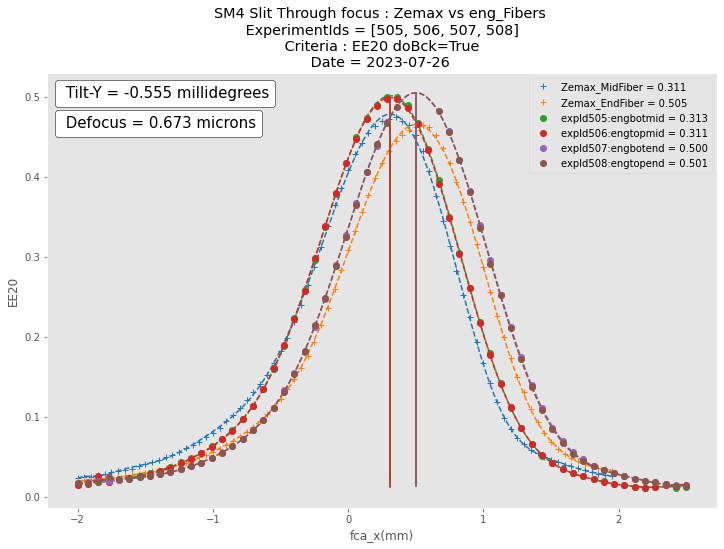

In [117]:
fig = plt.figure(figsize=(12, 8))
ax1 = fig.add_subplot(111)
j=2

if plotModel :
    ax1.plot(zemaxData.Slitdefocus, zemaxData.MidFiber, '+', color=colors[0], label='Zemax_MidFiber = %.3f' % zemaxMidFit.focus)
    ax1.plot(zemaxMidFit.x, zemaxMidFit.y, '--', color=colors[0])
    if vline:
        ax1.vlines(color=colors[0], **zemaxMidFit.vline)

    ax1.plot(zemaxData.Slitdefocus, zemaxData.ExtremeFiber, '+', color=colors[1], label='Zemax_EndFiber = %.3f' % zemaxEndFit.focus)
    ax1.plot(zemaxEndFit.x, zemaxEndFit.y, '--', color=colors[1])
    if vline:
        ax1.vlines(color=colors[1], **zemaxEndFit.vline)
else :
    print("Zemax model for engineering fibers non plotted")


    
for experimentId, df in cube2[cube2.EE20_nbh_flag].groupby('experimentId'):
    fit = thfocModel.query("experimentId==%d"%(experimentId))
    focus = focusModel.query("experimentId==%d and EE20=='%s'"%(experimentId, "EE20"))

    ax1.plot(df[index], df["EE20"], 'o', color=colors[j], 
    label='expId%d:%s = %.3f' % (experimentId, experiments.fiber[experimentId], focus[index]))

    ax1.plot(fit[index], fit["EE20"], '--', color=colors[j])

    if vline:
        ax1.vlines(x=focus[index], ymin=fit["EE20"].min(), ymax = fit["EE20"].max(), color=colors[j])
        j+=1
    
lns = [line for i, line in enumerate(ax1.get_lines()) if not i % 2]
labs = [line.get_label() for line in lns]

at = AnchoredText(" Tilt-Y = %.3f millidegrees"%(angle_degre*1000),
                  prop=dict(size=15), frameon=True,
                  loc='upper left',
                  )
at.patch.set_boxstyle("round,pad=0.,rounding_size=0.2")
ax1.add_artist(at)
at2 = AnchoredText(" Defocus = %.3f microns"%(focus_adjustment*1000),
                  prop=dict(size=15), frameon=True,
                  loc='lower left',
                  bbox_to_anchor=(0., 0.835),
                  bbox_transform=ax1.transAxes
                  )
at2.patch.set_boxstyle("round,pad=0.,rounding_size=0.2")


ax1.add_artist(at2)

ax1.legend(lns, labs)
ax1.set_xlabel('%s(mm)'%index)
ax1.set_ylabel("EE20")

plt.title(f'SM{smId} Slit Through focus : Zemax vs {str(focusModel.fiber[0][:3])}_Fibers \n ExperimentIds = {experimentIds} \n Criteria : EE20 doBck={doBck} \n Date = {datetime.date.today()}  ')
plt.grid()
plt.show()

if doSave : 
    fig.savefig(imgPath+f"Slit_Through_focus_SM{smId}_{focusModel.fiber[0][:3]}_Exp{experimentIds}_{datetime.date.today()}.png")

### 4.2. Saving graph

In [59]:
print(imgPath)

/data/drp/analysis/sm4/slitAlign/


In [89]:
# 4 : Displying the tilt value
print("There is a tilt of %.3f milidegrees" %(angle_degre*1000))

There is a tilt of 0.743 milidegrees
